# Price forecasts: モデル構築と評価
これまでの分析を踏まえ、以下の3つのモデルを構築し評価したい。
## Model A: Student-t Error Model
t分布を用いて、スパイクの影響を考慮したモデル。

今のところ考えているのは、小さなスパイクはこのモデルが効くのではということ。
$$
\log S_t
=
c
+
\alpha \log S_{t-1}
+
\beta x_t
+
\eta_t
$$

$$
\eta_t \sim t_\nu(0, \sigma^2)
$$

where

$$
x_t = (T_t - \bar{T}_t)^2
$$

## Model B: Jump Model
ジャンプ機構を明示的に組み込んだモデル。

このモデルでうまくスパイク発生確率を駆逐できれば、スパイクの初発を予測できる可能性がある。

$$
\log S_t
=
c
+
\alpha \log S_{t-1}
+
\beta x_t
+
\eta_t
+
I_t J_t
$$

$$
\eta_t \sim N(0, \sigma^2)
$$

$$
I_t \sim \mathrm{Bernoulli}(p_t)
$$

where

$$
x_t = (T_t - \bar{T}_t)^2
$$

## Model C: Student-t + Jump Model

$$
\log S_t
=
c
+
\alpha \log S_{t-1}
+
\beta x_t
+
\eta_t
+
I_t J_t
$$

$$
\eta_t \sim t_\nu(0, \sigma^2)
$$

$$
I_t \sim \mathrm{Bernoulli}(p_t)
$$

where

$$
x_t = (T_t - \bar{T}_t)^2
$$

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import seaborn

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("seaborn:", seaborn.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
seaborn: 0.13.2


In [ ]:
weekly_base = pd.read_csv(
    (PROJECT_DATA_DIR / "process/electricity/weekly_base_after_2017.csv")
)
weekly_base["datetime"] = pd.to_datetime(weekly_base["datetime"])

weekly_base = weekly_base.set_index("datetime")
weekly_base = weekly_base.asfreq("W")

weekly_base.head()

,tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff
datetime,,,,,,,,
2017-04-02,10.502321,8.528571,4.528571,12.857143,16.266307,-7.737736,59.872556,-0.385714
2017-04-09,10.566220,14.214286,10.514286,18.342857,16.228307,-2.014021,4.056281,5.685714
2017-04-16,10.523185,14.257143,9.328571,19.357143,16.192468,-1.935325,3.745482,0.042857
2017-04-23,9.521696,16.314286,12.271429,22.071429,16.194643,0.119643,0.014314,2.057143
2017-04-30,8.624762,16.157143,11.828571,21.057143,16.193985,-0.036842,0.001357,-0.157143


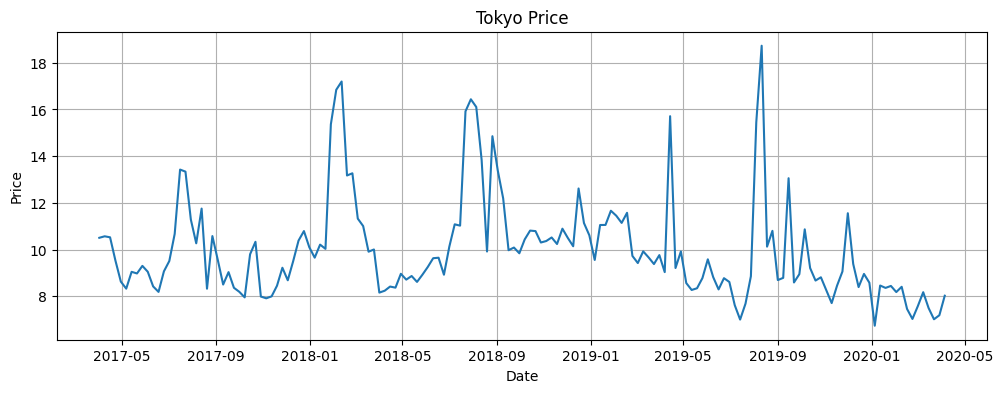

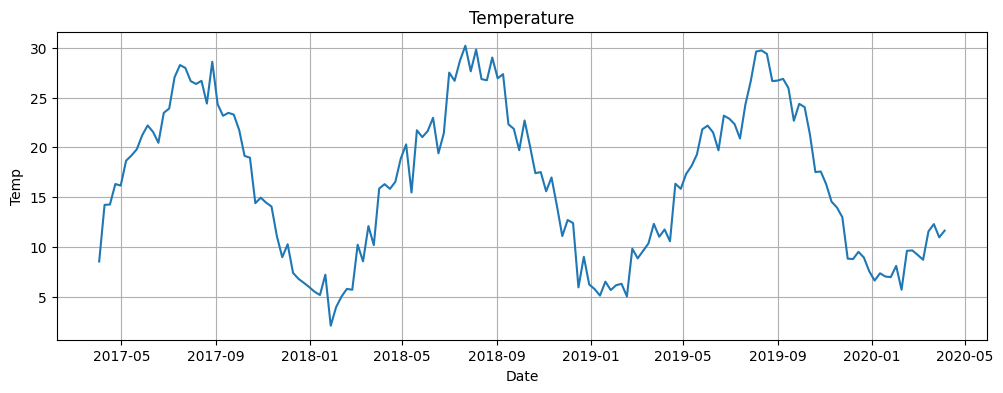

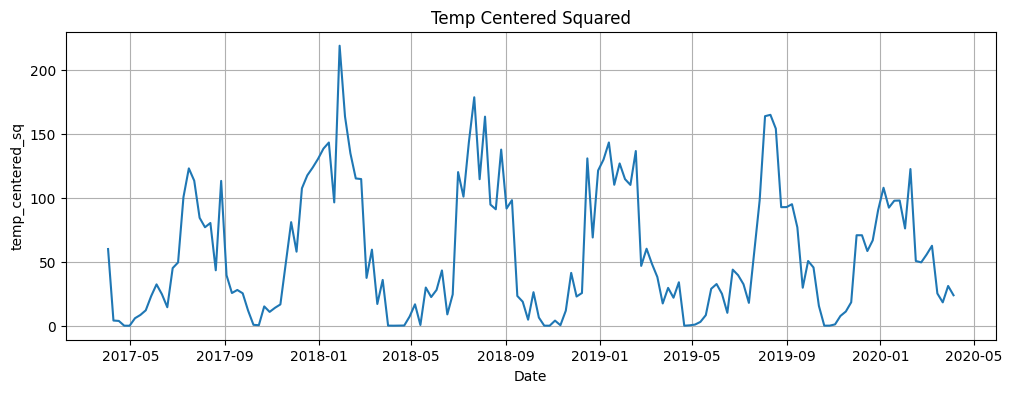

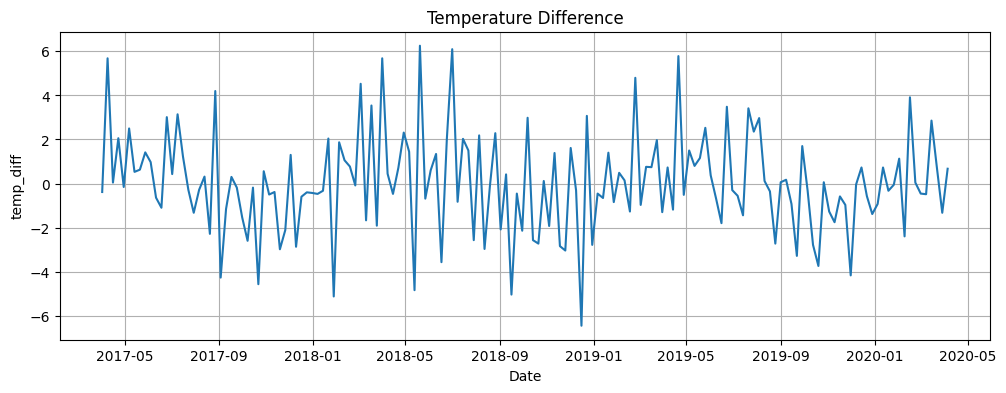

In [ ]:
import matplotlib.pyplot as plt

# 1. tokyo_price
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["tokyo_price"])

plt.title("Tokyo Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)

plt.show()


# 2. temp
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["temp"])

plt.title("Temperature")
plt.xlabel("Date")
plt.ylabel("Temp")

plt.grid(True)

plt.show()


# 3. temp_centered_sq
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["temp_centered_sq"])

plt.title("Temp Centered Squared")
plt.xlabel("Date")
plt.ylabel("temp_centered_sq")

plt.grid(True)

plt.show()


# 4. temp_diff
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["temp_diff"])

plt.title("Temperature Difference")
plt.xlabel("Date")
plt.ylabel("temp_diff")

plt.grid(True)

plt.show()